# Load

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
energy_efficiency = fetch_ucirepo(id=242)

# data (as pandas dataframes)
X = energy_efficiency.data.features
y = energy_efficiency.data.targets

# metadata
print(energy_efficiency.metadata)

# variable information
print(energy_efficiency.variables)


{'uci_id': 242, 'name': 'Energy Efficiency', 'repository_url': 'https://archive.ics.uci.edu/dataset/242/energy+efficiency', 'data_url': 'https://archive.ics.uci.edu/static/public/242/data.csv', 'abstract': 'This study looked into assessing the heating load and cooling load requirements of buildings (that is, energy efficiency) as a function of building parameters.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 768, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y1', 'Y2'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C51307', 'creators': ['Athanasios Tsanas', 'Angeliki Xifara'], 'intro_paper': {'ID': 379, 'type': 'NATIVE', 'title': 'Accurate quantitative estimation of energy performance of residential buildings using statistical machine 

In [3]:
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [4]:
# # Create a dictionary to map current column names to their descriptions
# column_descriptions = {
#     'X1': 'Relative Compactness',
#     'X2': 'Surface Area',
#     'X3': 'Wall Area',
#     'X4': 'Roof Area',
#     'X5': 'Overall Height',
#     'X6': 'Orientation',
#     'X7': 'Glazing Area',
#     'X8': 'Glazing Area Distribution',
#     'Y1': 'Heating Load',
#     'Y2': 'Cooling Load'
# }

# # Rename the columns in the df_plot DataFrame
# df_plot = df_plot.rename(columns=column_descriptions)

# # Display the first few rows of the dataframe with renamed columns
# display(df_plot.head())

# Analysis

In [ ]:
import numpy as np
print(X.info())
display(X.select_dtypes(include=[np.number]).describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 48.1 KB
None


,X1,X2,X3,X4,X5,X6,X7,X8
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000


### isna

In [ ]:
print("Nan values:")
display(X.isna().sum().sort_values(ascending=False))
display(y.isna().sum().sort_values(ascending=False))


Nan values:


,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0


,0
Y1,0
Y2,0


### Distribution

X1: max=0.98, unique=12, bins=27, discrete=False


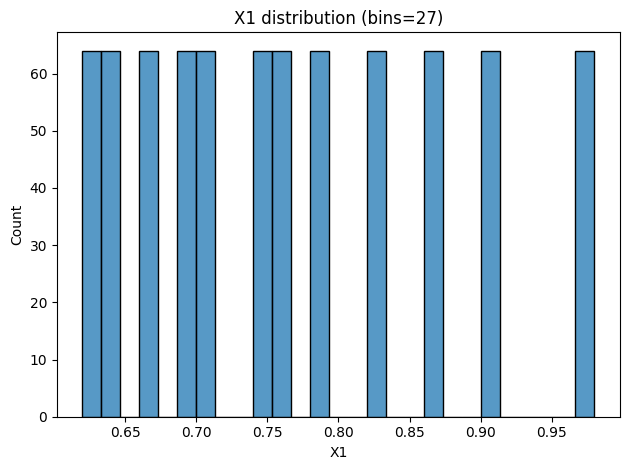

X2: max=808.5, unique=12, bins=27, discrete=False


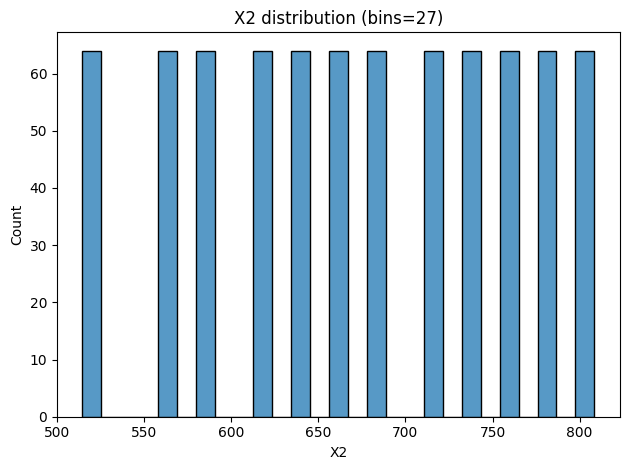

X3: max=416.5, unique=7, bins=27, discrete=False


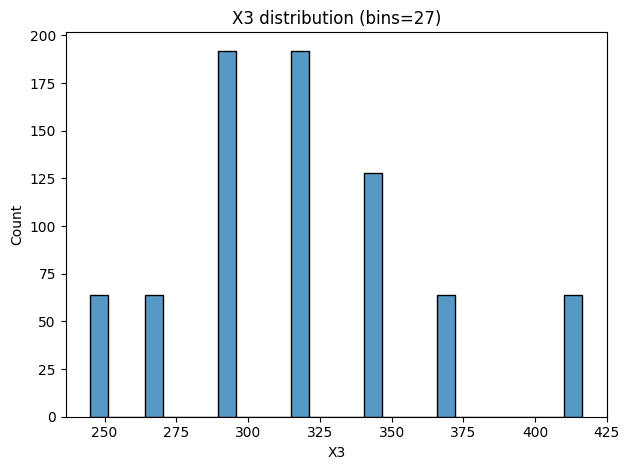

X4: max=220.5, unique=4, bins=27, discrete=False


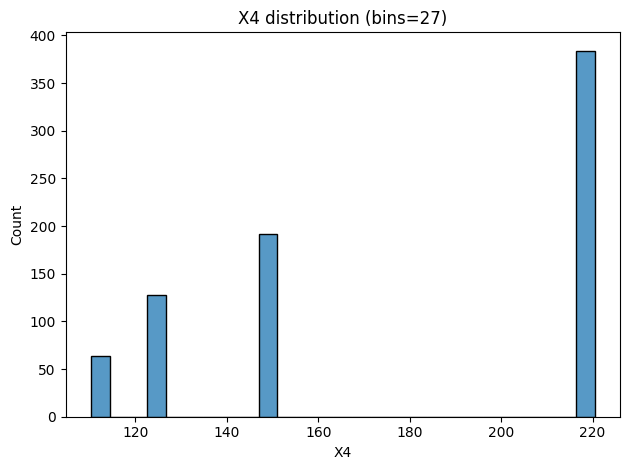

X5: max=7.0, unique=2, bins=27, discrete=False


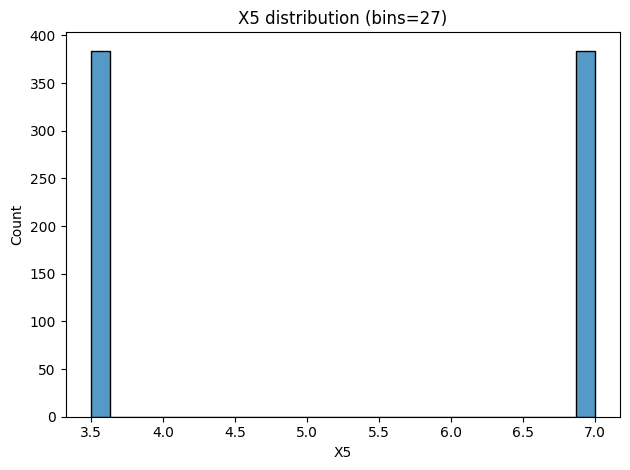

X6: max=5, unique=4, bins=4, discrete=True


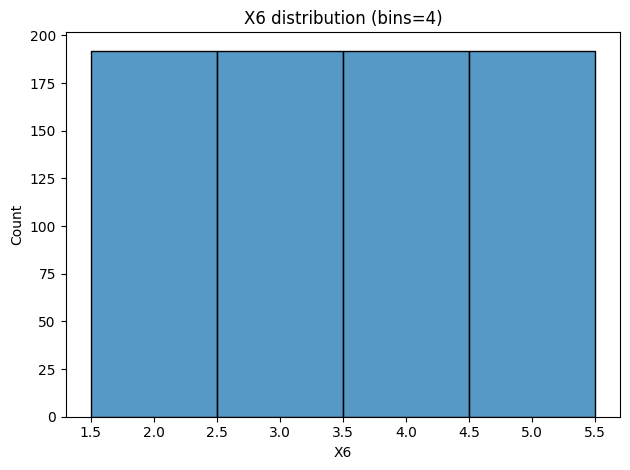

X7: max=0.4, unique=4, bins=27, discrete=False


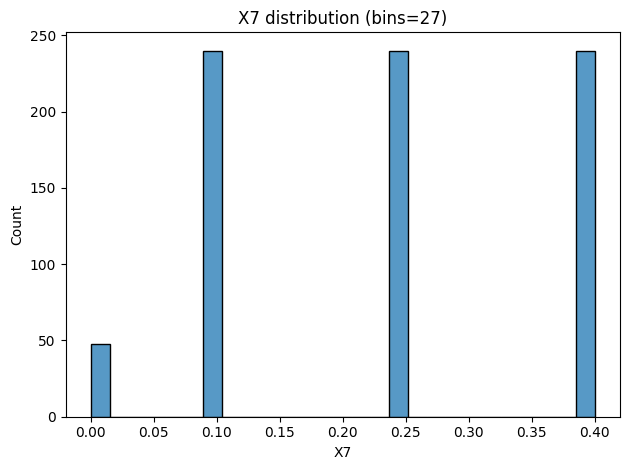

X8: max=5, unique=6, bins=6, discrete=True


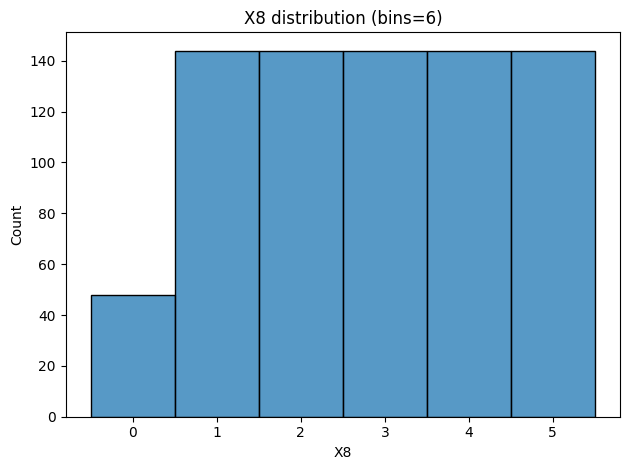

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

num_cols = X.select_dtypes(include=[np.number]).columns
for c in num_cols:
  if c == 'CustomerID':
    continue
  cleaned = X[c].dropna()
  max_val = cleaned.max()
  n = len(cleaned)
  # Decide bins:
  # If data look like small-range integers (few unique values) use that count (discrete histogram)
  n_unique = cleaned.nunique()
  use_discrete = False
  if pd.api.types.is_integer_dtype(cleaned) and 1 < n_unique <= 20:
      bins = n_unique
      use_discrete = True
  else:
      # Fallback: Freedman–Diaconis inspired simple heuristic (sqrt fallback) capped
      # sqrt(n) is a simple rule-of-thumb; keep within [10, 40]
      bins = int(np.sqrt(n)) if n > 0 else 1
      bins = max(10, min(40, bins))
  print(f'{c}: max={max_val}, unique={n_unique}, bins={bins}, discrete={use_discrete}')
  sns.histplot(cleaned, bins=bins, discrete=use_discrete)
  plt.title(f'{c} distribution (bins={bins})')
  plt.tight_layout()
  plt.show()

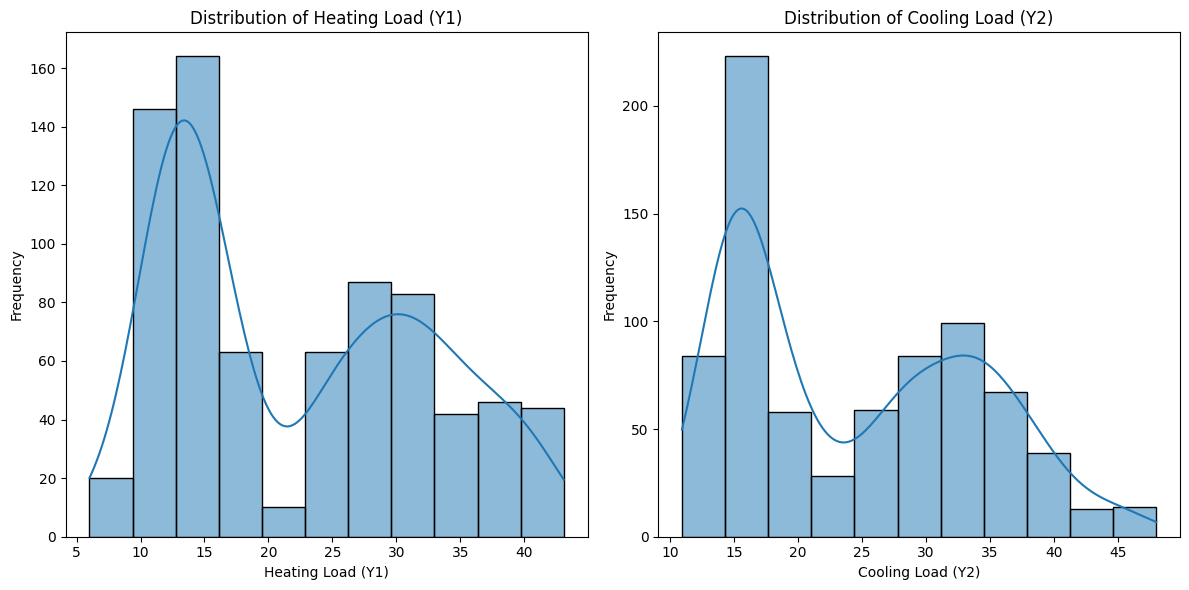

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of the target variables Y1 and Y2
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(y['Y1'], ax=axes[0], kde=True)
axes[0].set_title('Distribution of Heating Load (Y1)')
axes[0].set_xlabel('Heating Load (Y1)')
axes[0].set_ylabel('Frequency')

sns.histplot(y['Y2'], ax=axes[1], kde=True)
axes[1].set_title('Distribution of Cooling Load (Y2)')
axes[1].set_xlabel('Cooling Load (Y2)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Distribution by Class & df_plot

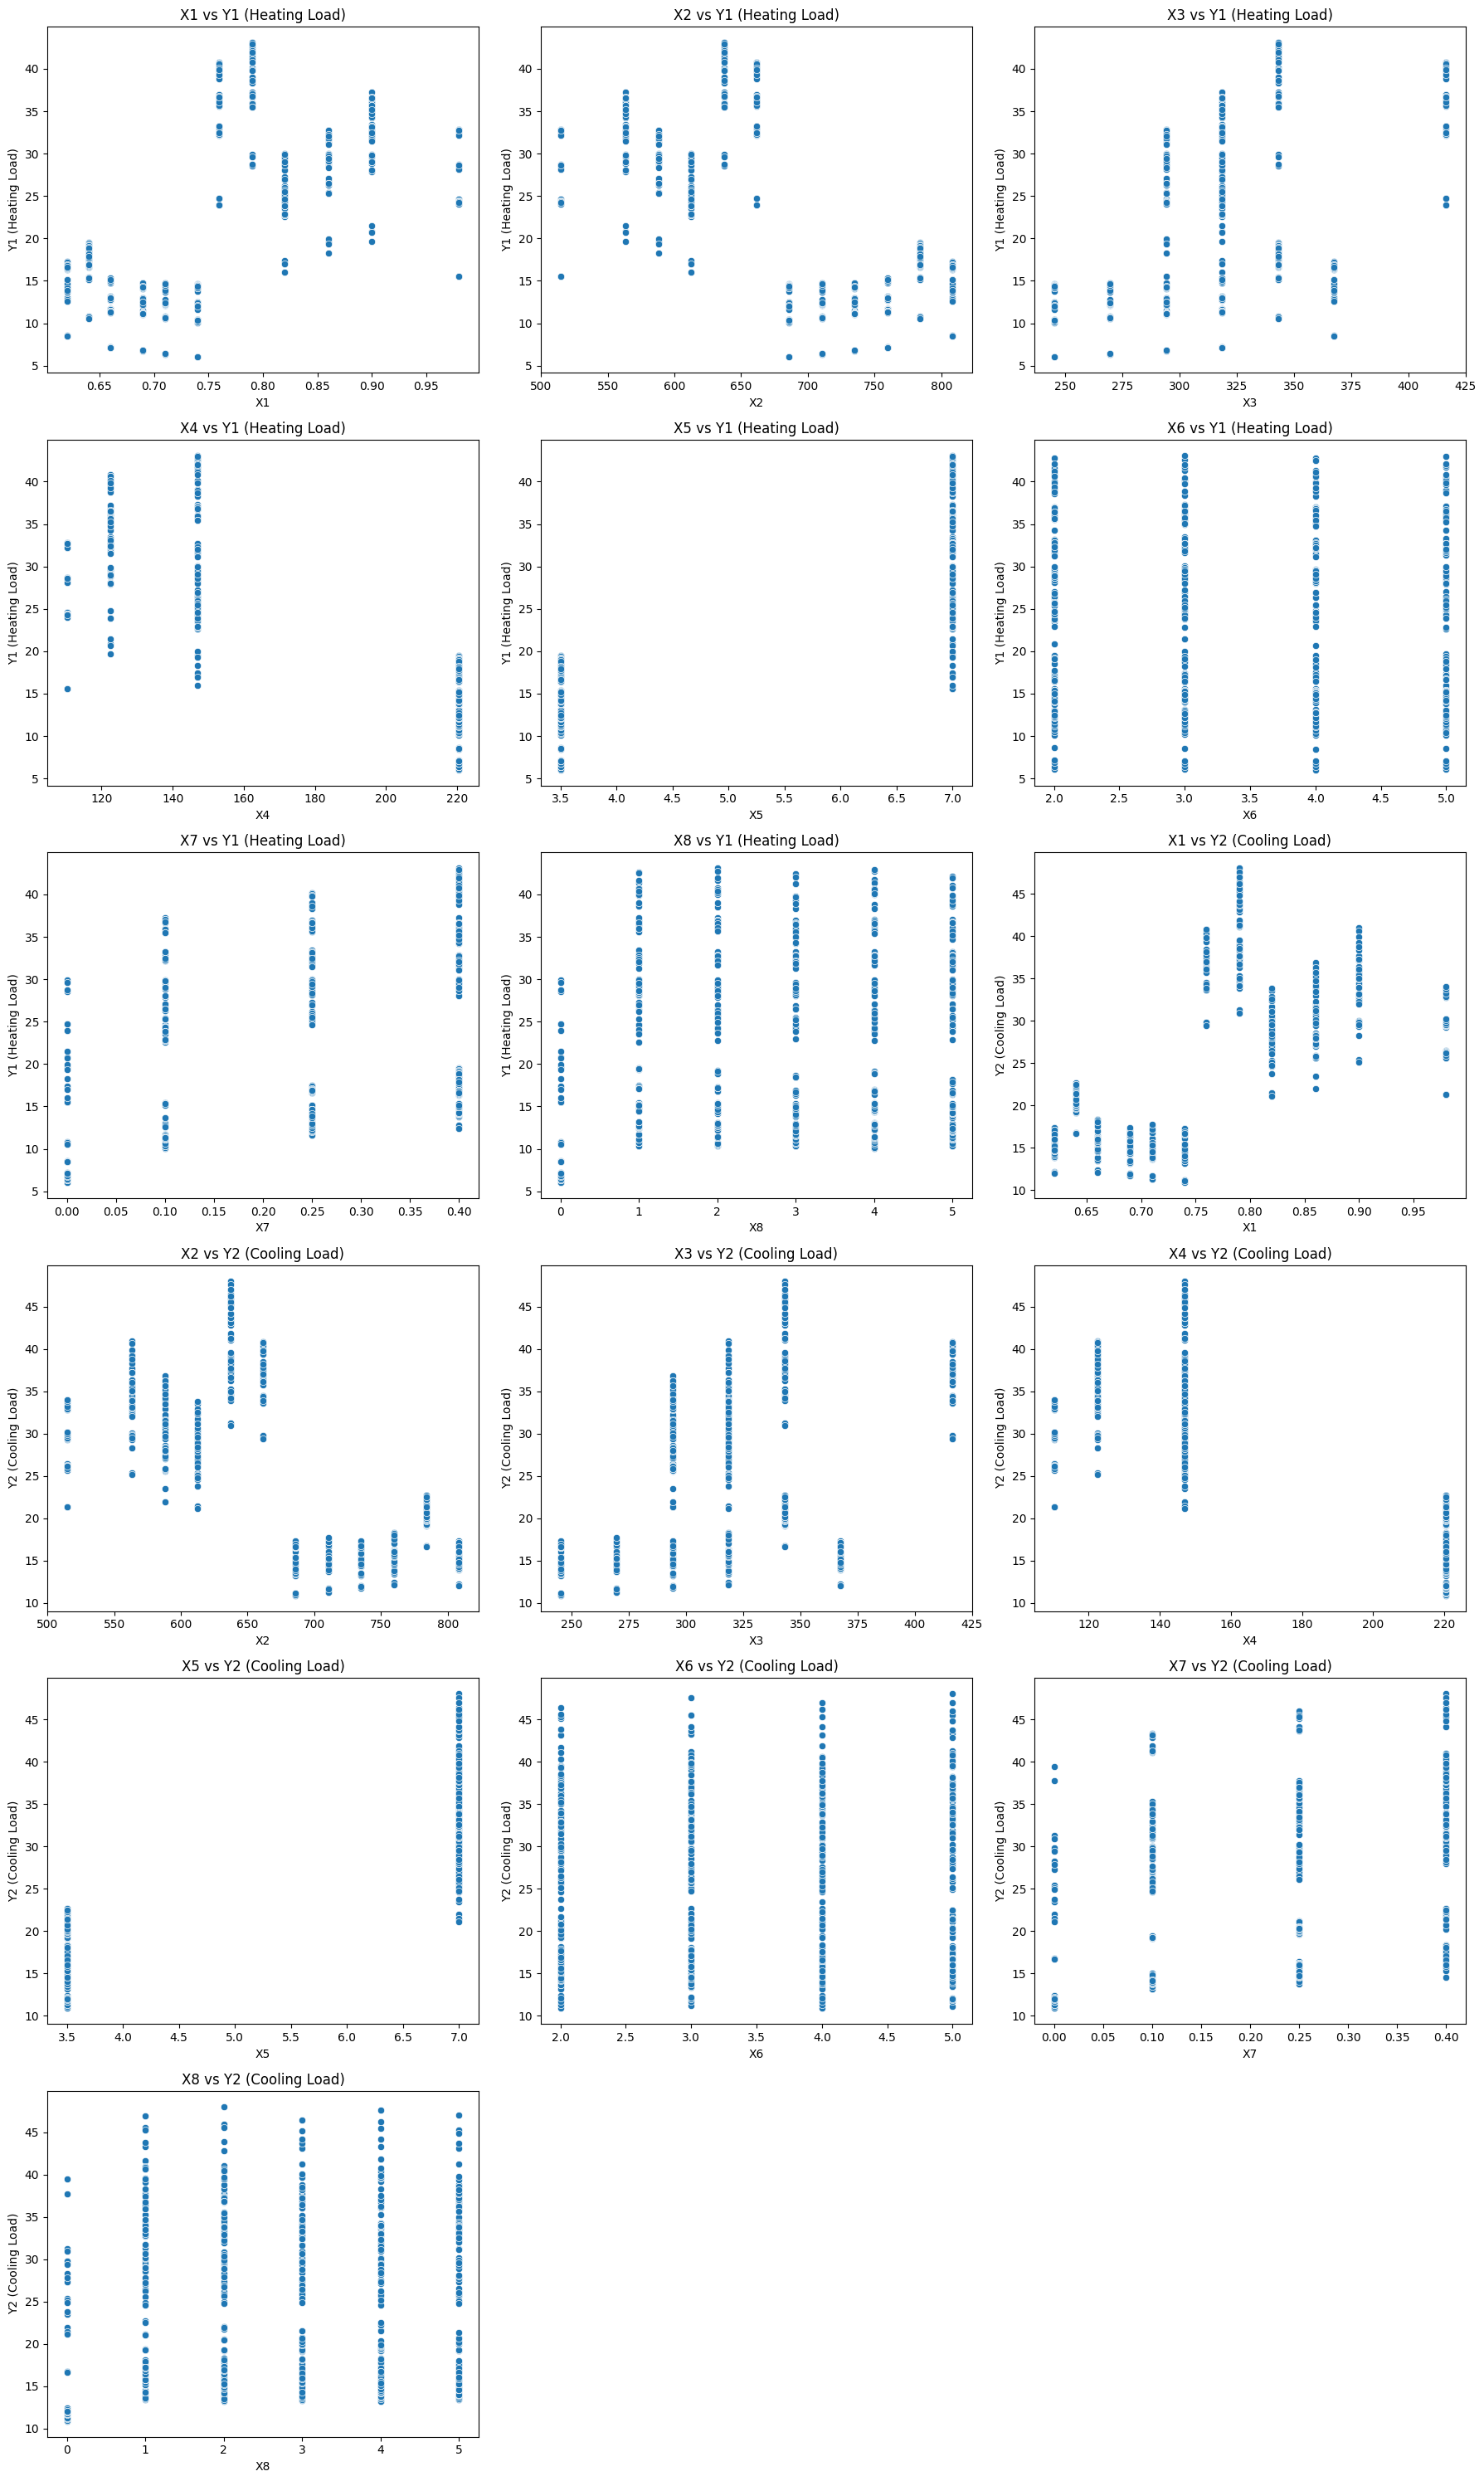

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Combine features (X) and target (y) for plotting
df_plot = X.copy()
df_plot['Y1'] = y['Y1']
df_plot['Y2'] = y['Y2']

# Get numerical column names from X
num_cols = X.select_dtypes(include=['number']).columns

# Determine the number of rows and columns needed for subplots
n_cols = 3
n_rows_Y1 = math.ceil(len(num_cols) / n_cols)
n_rows_Y2 = math.ceil(len(num_cols) / n_cols)
# Total rows needed for both target variables
total_rows = n_rows_Y1 + n_rows_Y2

# Create subplots
fig, axes = plt.subplots(total_rows, n_cols, figsize=(18, total_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot scatter plots for Y1
for i, col in enumerate(num_cols):
    sns.scatterplot(x=col, y='Y1', data=df_plot, ax=axes[i])
    axes[i].set_title(f'{col} vs Y1 (Heating Load)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Y1 (Heating Load)')

# Plot scatter plots for Y2
for i, col in enumerate(num_cols):
    sns.scatterplot(x=col, y='Y2', data=df_plot, ax=axes[i + len(num_cols)])
    axes[i + len(num_cols)].set_title(f'{col} vs Y2 (Cooling Load)')
    axes[i + len(num_cols)].set_xlabel(col)
    axes[i + len(num_cols)].set_ylabel('Y2 (Cooling Load)')


# Hide any unused subplots
for j in range(len(num_cols) * 2 , len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Corr matrix

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
Relative Compactness,1.000000e+00,-9.919015e-01,-2.037817e-01,-8.688234e-01,8.277473e-01,4.678592e-17,-2.960552e-15,-7.107006e-16,0.622272,0.634339
Surface Area,-9.919015e-01,1.000000e+00,1.955016e-01,8.807195e-01,-8.581477e-01,-3.459372e-17,3.636925e-15,2.438409e-15,-0.658120,-0.672999
Wall Area,-2.037817e-01,1.955016e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-2.429499e-17,-8.567455e-17,2.067384e-16,0.455671,0.427117
Roof Area,-8.688234e-01,8.807195e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-5.830058e-17,-1.759011e-15,-1.078071e-15,-0.861828,-0.862547
Overall Height,8.277473e-01,-8.581477e-01,2.809757e-01,-9.725122e-01,1.000000e+00,4.492205e-17,1.489134e-17,-2.920613e-17,0.889431,0.895785
Orientation,4.678592e-17,-3.459372e-17,-2.429499e-17,-5.830058e-17,4.492205e-17,1.000000e+00,-9.406007e-16,-2.549352e-16,-0.002587,0.014290
Glazing Area,-2.960552e-15,3.636925e-15,-8.567455e-17,-1.759011e-15,1.489134e-17,-9.406007e-16,1.000000e+00,2.129642e-01,0.269841,0.207505
Glazing Area Distribution,-7.107006e-16,2.438409e-15,2.067384e-16,-1.078071e-15,-2.920613e-17,-2.549352e-16,2.129642e-01,1.000000e+00,0.087368,0.050525
Heating Load,6.222722e-01,-6.581202e-01,4.556712e-01,-8.618283e-01,8.894307e-01,-2.586534e-03,2.698410e-01,8.736759e-02,1.000000,0.975862
Cooling Load,6.343391e-01,-6.729989e-01,4.271170e-01,-8.625466e-01,8.957852e-01,1.428960e-02,2.075050e-01,5.052512e-02,0.975862,1.000000


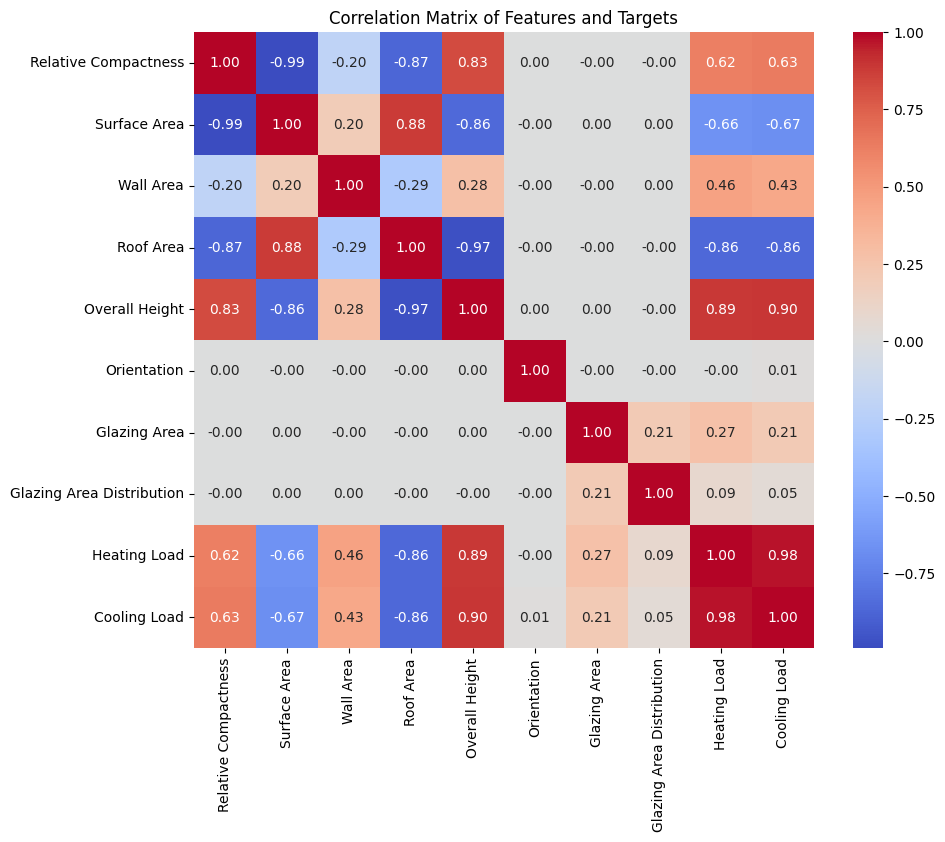

In [ ]:
# Calculate the correlation matrix
corr_matrix = df_plot.corr()

# Display the correlation matrix
display(corr_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Targets')
plt.show()

# split scale

## Data splitting

In [5]:
from sklearn.model_selection import train_test_split

# Split data for Y1
X_train, X_test, y1_train, y1_test = train_test_split(X, y['Y1'], test_size=0.2, random_state=42)

# Split data for Y2
X_train, X_test, y2_train, y2_test = train_test_split(X, y['Y2'], test_size=0.2, random_state=42)

## Feature scaling


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (614, 8)
Shape of X_test_scaled: (154, 8)


# nn

## y1 model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_y1 = Sequential(
    [
        Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])

# Compile the model for Heating Load (Y1)
model_y1.compile(loss='mse', optimizer='adam', metrics=['mae'])

history_y1 = model_y1.fit(X_train_scaled, y1_train, epochs=100, batch_size=32, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


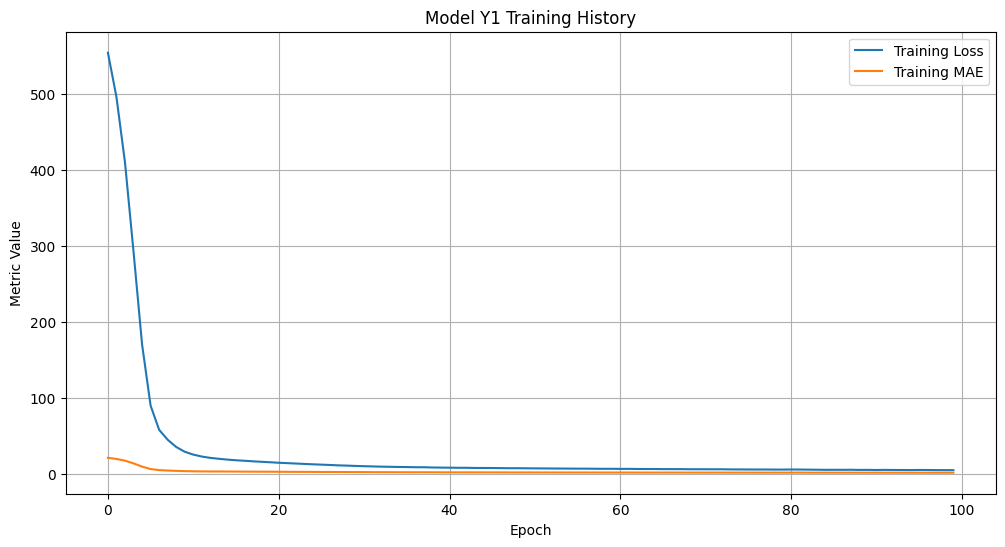

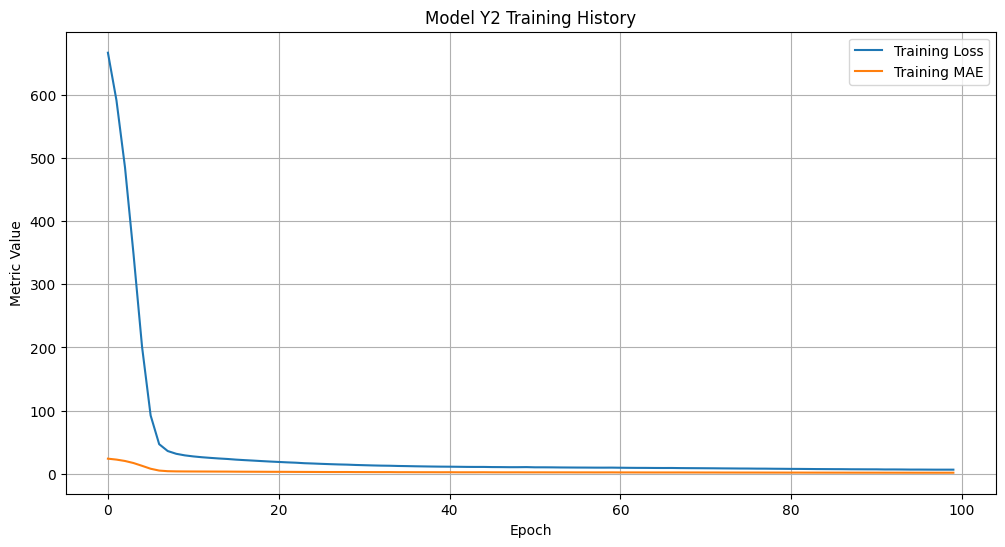

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history_y1.history['loss'], label='Training Loss')
plt.plot(history_y1.history['mae'], label='Training MAE')
plt.title('Model Y1 Training History')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Train the model for Heating Load (Y1)
history_y1 = model_y1.fit(X_train_scaled, y1_train, epochs=100, batch_size=32, verbose=0)

print("Training finished for model_y1.")

Training finished for model_y1.


## Model evaluation (heating load)

### Subtask:
Evaluate the performance of the Heating Load model on the test data.


**Reasoning**:
Evaluate the trained Heating Load model on the scaled test data and print the results.



In [ ]:
# Evaluate the trained model for Heating Load (Y1) on the test data
evaluation_y1 = model_y1.evaluate(X_test_scaled, y1_test, verbose=0)

# Print the evaluation results
print(f"Heating Load Model Evaluation on Test Data:")
print(f"  Loss (MSE): {evaluation_y1[0]:.4f}")
print(f"  MAE: {evaluation_y1[1]:.4f}")

Heating Load Model Evaluation on Test Data:
  Loss (MSE): 5.5526
  MAE: 1.5650


## Model definition (cooling load)

### Subtask:
Define a simple neural network model for predicting the Cooling Load (Y2).


**Reasoning**:
Define the simple neural network model for predicting Cooling Load (Y2) as specified in the instructions, including the input layer with the correct input dimension, a hidden layer, and the output layer.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_y2 = Sequential(
    [
        Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ]
)

# Compile the model for Cooling Load (Y2) including MAE as a metric
model_y2.compile(loss='mse', optimizer='adam', metrics=['mse', 'mae'])

history_y2 = model_y2.fit(X_train_scaled, y2_train, epochs=100, batch_size=32, validation_data=(X_test_scaled, y2_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


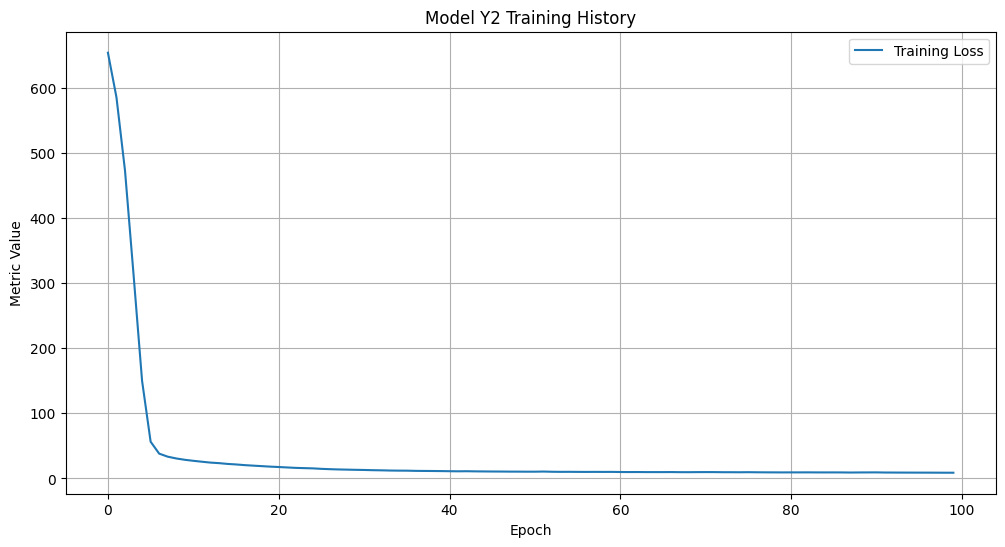

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history_y2.history['loss'], label='Training Loss')
plt.plot(history_y2.history['mae'], label='Training MAE')
plt.title('Model Y2 Training History')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate the trained model for Cooling Load (Y2) on the test data
evaluation_y2 = model_y2.evaluate(X_test_scaled, y2_test, verbose=0)

# Print the evaluation results
print(f"Cooling Load Model Evaluation on Test Data:")
print(f"  Loss (MSE): {evaluation_y2[0]:.4f}")
print(f"  MAE: {evaluation_y2[1]::.4f}")

Cooling Load Model Evaluation on Test Data:
  Loss (MSE): 6.3611


ValueError: Invalid format specifier ':.4f' for object of type 'float'

**Reasoning**:
Correct the format specifier in the print statement for MAE and re-evaluate the model.



In [ ]:
# Evaluate the trained model for Cooling Load (Y2) on the test data
evaluation_y2 = model_y2.evaluate(X_test_scaled, y2_test, verbose=0)

# Print the evaluation results
print(f"Cooling Load Model Evaluation on Test Data:")
print(f"  Loss (MSE): {evaluation_y2[0]:.4f}")
print(f"  MAE: {evaluation_y2[1]:.4f}")

Cooling Load Model Evaluation on Test Data:
  Loss (MSE): 6.3611
  MAE: 1.7794


# NN


## Implement k-fold cross-validation


In [7]:
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# Define the number of folds
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store evaluation results and history for each fold
y1_fold_results = []
y2_fold_results = []
y1_fold_histories = []
y2_fold_histories = []

# K-Fold Cross-Validation for Y1
print(f"Performing {n_splits}-fold cross-validation for Heating Load (Y1)...")
fold_num = 1
for train_index, val_index in kf.split(X_train_scaled, y1_train):
    print(f"  Fold {fold_num}/{n_splits}")
    X_train_fold, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    y1_train_fold, y1_val_fold = y1_train.iloc[train_index], y1_train.iloc[val_index]

    # Instantiate and compile the model for Y1 for the current fold
    model_y1_fold = Sequential([
        Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'),
        # Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model_y1_fold.compile(loss='mse', optimizer='adam', metrics=['mae'])

    # Train the model for the current fold and store the history
    history_y1_fold = model_y1_fold.fit(X_train_fold, y1_train_fold, epochs=100, batch_size=32, verbose=0)

    # Evaluate the model on the validation data for the current fold
    loss_y1, mae_y1 = model_y1_fold.evaluate(X_val_fold, y1_val_fold, verbose=0)
    y1_fold_results.append({'loss': loss_y1, 'mae': mae_y1})
    y1_fold_histories.append(history_y1_fold)
    print(f"    Validation Loss (MSE): {loss_y1:.4f}, Validation MAE: {mae_y1:.4f}")
    fold_num += 1

# K-Fold Cross-Validation for Y2
print(f"\nPerforming {n_splits}-fold cross-validation for Cooling Load (Y2)...")
fold_num = 1
for train_index, val_index in kf.split(X_train_scaled, y2_train):
    print(f"  Fold {fold_num}/{n_splits}")
    X_train_fold, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    y2_train_fold, y2_val_fold = y2_train.iloc[train_index], y2_train.iloc[val_index]

    # Instantiate and compile the model for Y2 for the current fold
    model_y2_fold = Sequential([
        Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model_y2_fold.compile(loss='mse', optimizer='adam', metrics=['mae'])

    # Train the model for the current fold and store the history
    history_y2_fold = model_y2_fold.fit(X_train_fold, y2_train_fold, epochs=100, batch_size=32, verbose=0)


    # Evaluate the model on the validation data for the current fold
    loss_y2, mae_y2 = model_y2_fold.evaluate(X_val_fold, y2_val_fold, verbose=0)
    y2_fold_results.append({'loss': loss_y2, 'mae': mae_y2})
    y2_fold_histories.append(history_y2_fold)
    print(f"    Validation Loss (MSE): {loss_y2:.4f}, Validation MAE: {mae_y2:.4f}")
    fold_num += 1

print("\nK-Fold Cross-Validation completed.")

# Train final models on the entire training dataset after cross-validation
print("\nTraining final models on the entire training dataset...")

# Final model for Y1
model_y1_final = Sequential([
    Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dense(1, activation='linear')
])
model_y1_final.compile(loss='mse', optimizer='adam', metrics=['mae'])
model_y1_final.fit(X_train_scaled, y1_train, epochs=100, batch_size=32, verbose=0)
print("Final model for Y1 trained.")

# Final model for Y2
model_y2_final = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model_y2_final.compile(loss='mse', optimizer='adam', metrics=['mae'])
model_y2_final.fit(X_train_scaled, y2_train, epochs=100, batch_size=32, verbose=0)
print("Final model for Y2 trained.")

Performing 5-fold cross-validation for Heating Load (Y1)...
  Fold 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    Validation Loss (MSE): 13.1777, Validation MAE: 2.5001
  Fold 2/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    Validation Loss (MSE): 14.9516, Validation MAE: 2.6295
  Fold 3/5


...

    Validation Loss (MSE): 8.8729, Validation MAE: 2.1248

K-Fold Cross-Validation completed.

Training final models on the entire training dataset...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final model for Y1 trained.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final model for Y2 trained.


## Evaluate cross-validation results


Plotting per-epoch history for Heating Load (Y1) cross-validation folds...


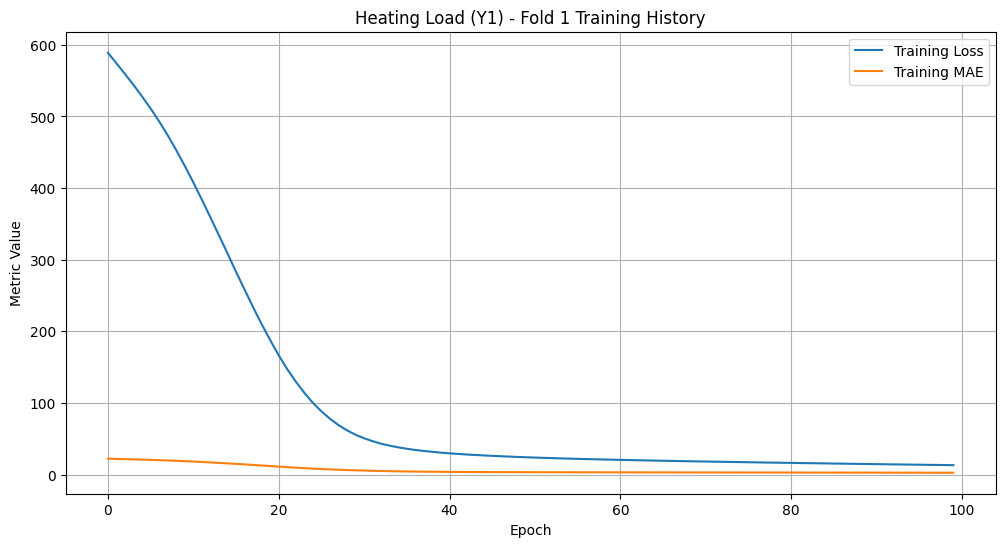

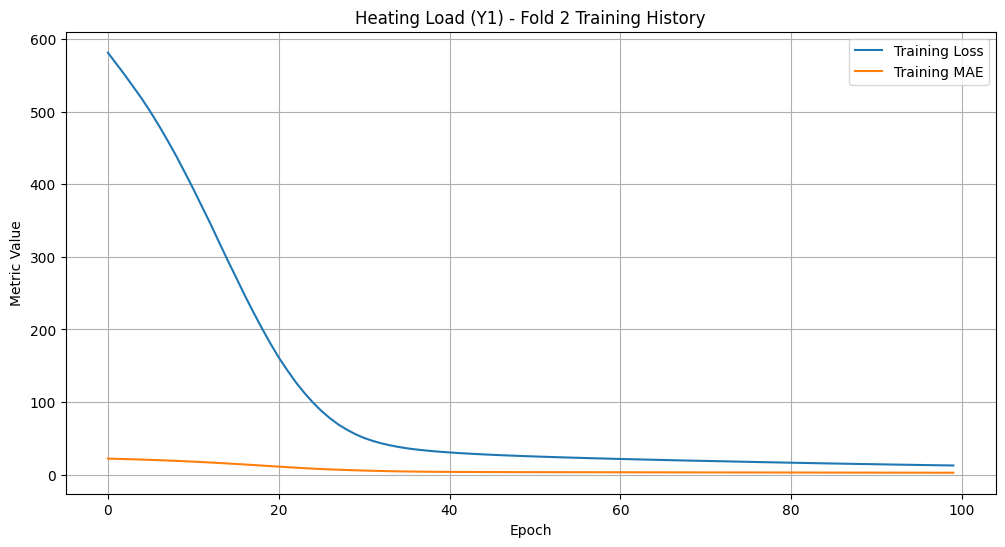

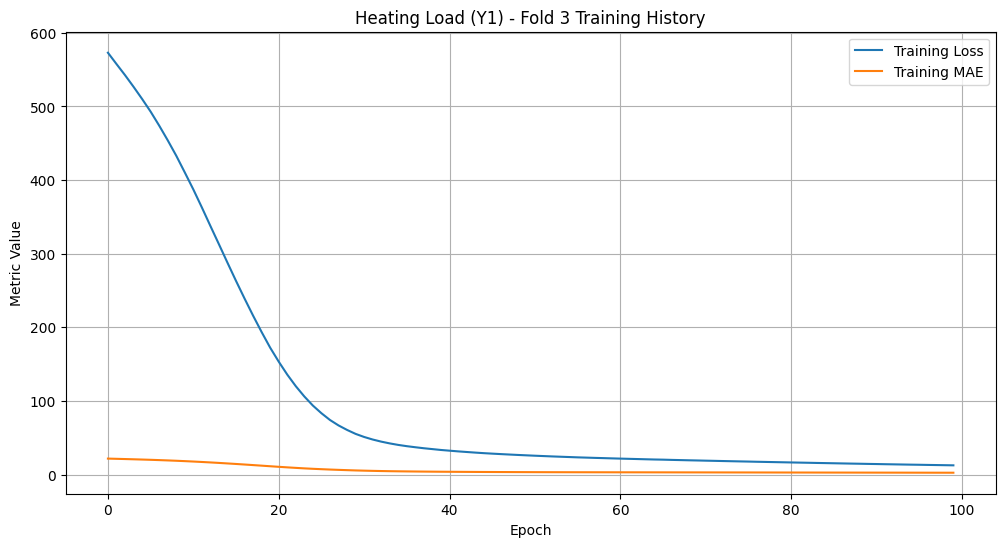

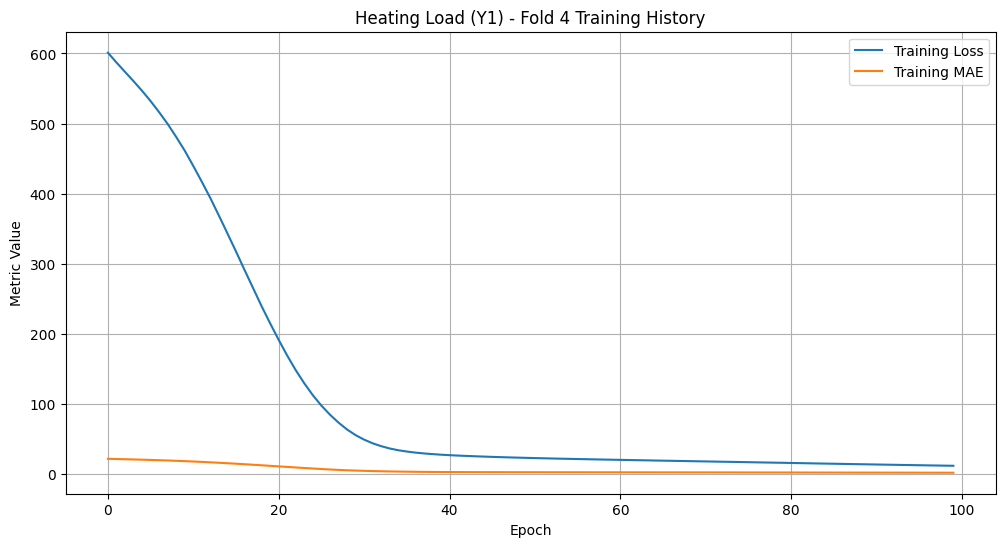

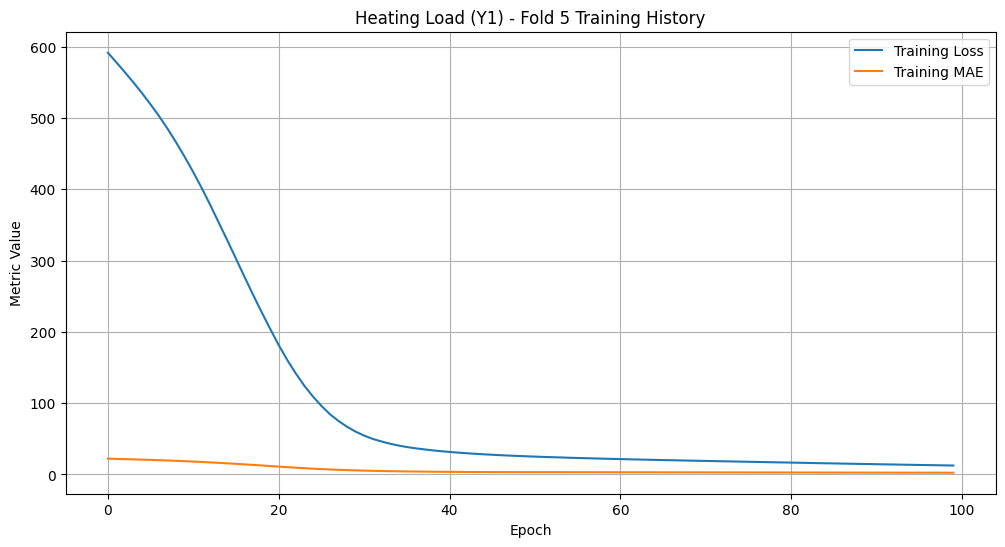


Plotting per-epoch history for Cooling Load (Y2) cross-validation folds...


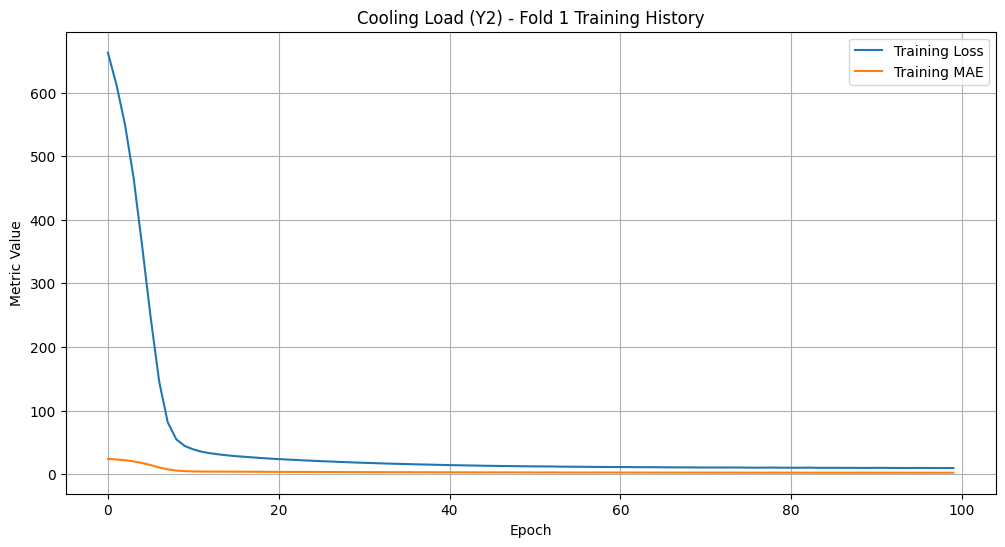

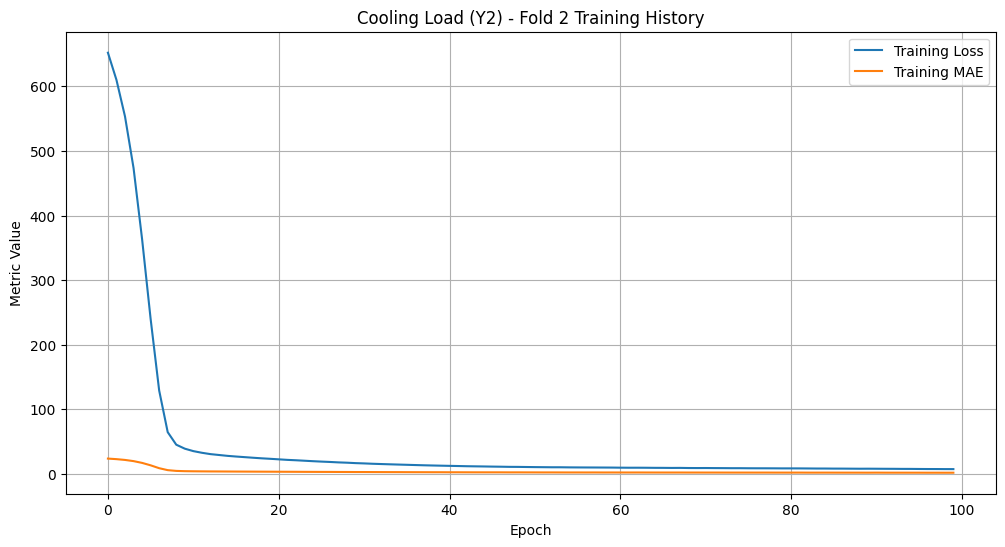

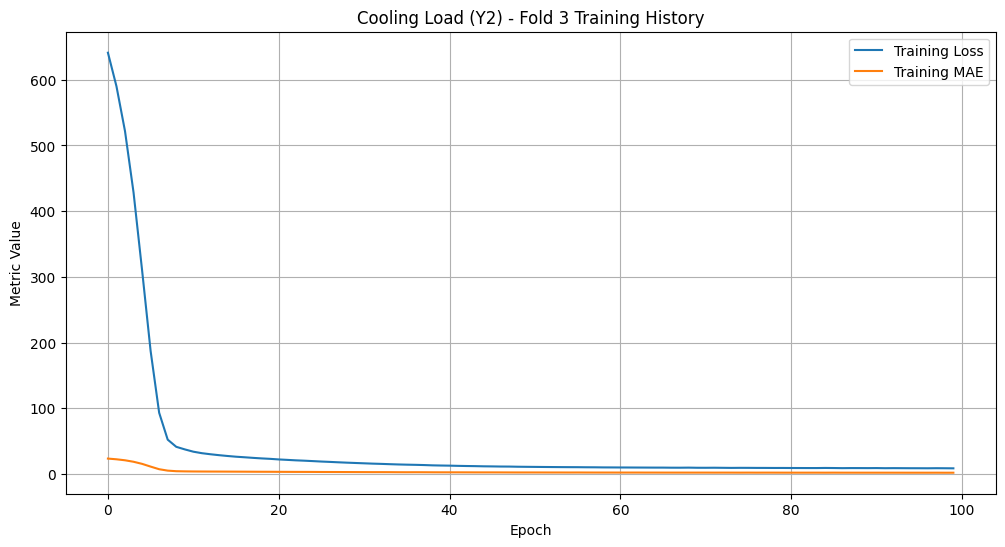

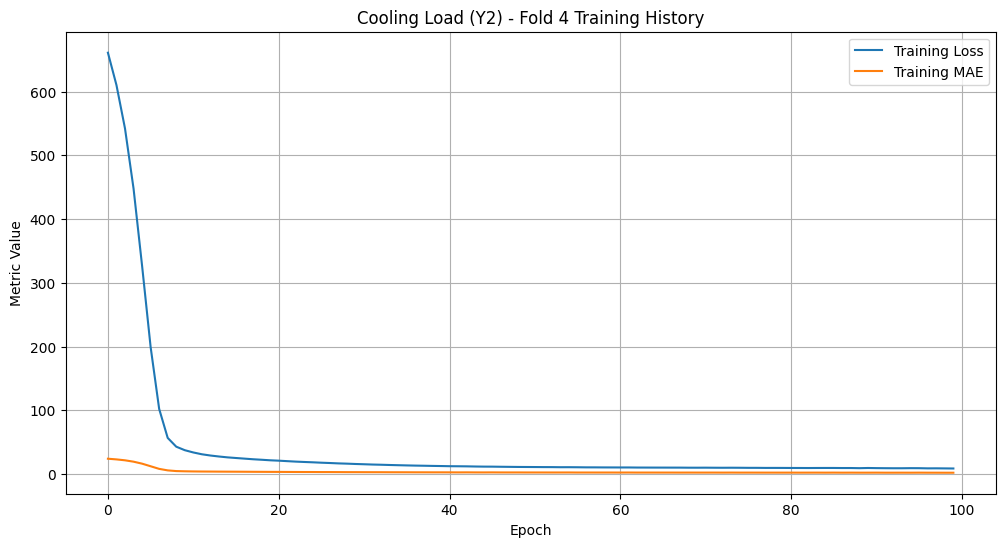

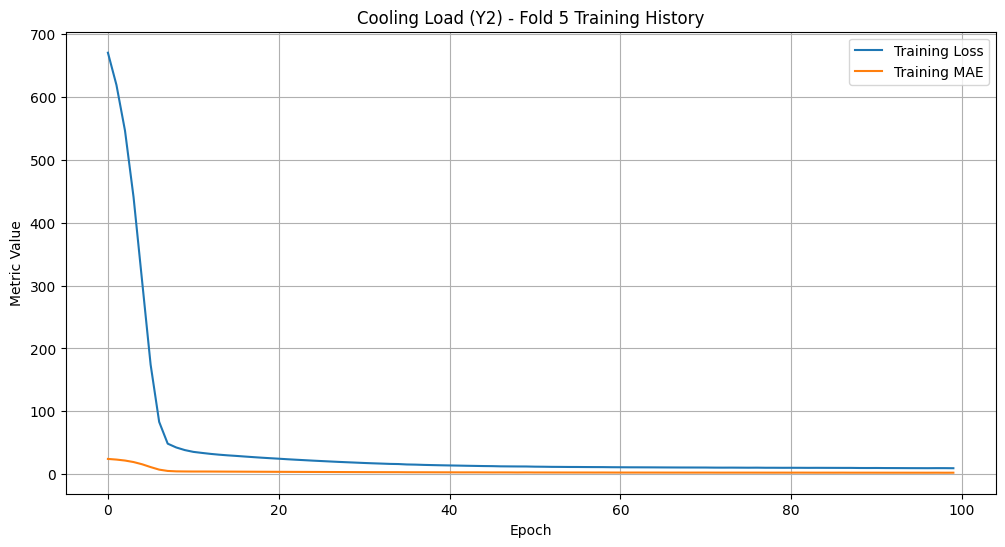

In [8]:
import matplotlib.pyplot as plt

# Plotting per-epoch history for each fold for Y1
print("Plotting per-epoch history for Heating Load (Y1) cross-validation folds...")
for i, history in enumerate(y1_fold_histories):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    # The cross-validation models were not trained with validation data, so there is no validation loss or MAE to plot.
    # plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.plot(history.history['mae'], label='Training MAE')
    # plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title(f'Heating Load (Y1) - Fold {i+1} Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plotting per-epoch history for each fold for Y2
print("\nPlotting per-epoch history for Cooling Load (Y2) cross-validation folds...")
for i, history in enumerate(y2_fold_histories):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    # The cross-validation models were not trained with validation data, so there is no validation loss or MAE to plot.
    # plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.plot(history.history['mae'], label='Training MAE')
    # plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title(f'Cooling Load (Y2) - Fold {i+1} Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.legend()
    plt.grid(True)
    plt.show()

## final

In [9]:
model_y1_final = Sequential([
    Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dense(1, activation='linear')
])
model_y1_final.compile(loss='mse', optimizer='adam', metrics=['mae'])
model_y1_final.fit(X_train_scaled, y1_train, epochs=100, batch_size=32, verbose=0)
print("Final model for Y1 trained.")

# Final model for Y2
model_y2_final = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model_y2_final.compile(loss='mse', optimizer='adam', metrics=['mae'])
model_y2_final.fit(X_train_scaled, y2_train, epochs=100, batch_size=32, verbose=0)
print("Final model for Y2 trained.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final model for Y1 trained.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final model for Y2 trained.


## Test

In [11]:
from sklearn.metrics import r2_score

# Evaluate the final trained model for Heating Load (Y1) on the test data
evaluation_y1_final = model_y1_final.evaluate(X_test_scaled, y1_test, verbose=0)

# Predict on the test set using the final models
y1_pred = model_y1_final.predict(X_test_scaled)
y2_pred = model_y2_final.predict(X_test_scaled)

# Calculate R² scores
r2_y1 = r2_score(y1_test, y1_pred)
r2_y2 = r2_score(y2_test, y2_pred)

# Print the evaluation results for the final Y1 model
print(f"Final Heating Load Model Evaluation on Test Data:")
print(f"  Loss (MSE): {evaluation_y1_final[0]:.4f}")
print(f"  MAE: {evaluation_y1_final[1]:.4f}")
print(f"  R2: {r2_y1:.4f}")


# Evaluate the final trained model for Cooling Load (Y2) on the test data
evaluation_y2_final = model_y2_final.evaluate(X_test_scaled, y2_test, verbose=0)

# Print the evaluation results for the final Y2 model
print(f"\nFinal Cooling Load Model Evaluation on Test Data:")
print(f"  Loss (MSE): {evaluation_y2_final[0]:.4f}")
print(f"  MAE: {evaluation_y2_final[1]:.4f}")
print(f"  R2: {r2_y2:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Final Heating Load Model Evaluation on Test Data:
  Loss (MSE): 11.9623
  MAE: 2.4412
  R2: 0.8852

Final Cooling Load Model Evaluation on Test Data:
  Loss (MSE): 8.3271
  MAE: 1.9352
  R2: 0.9101


# Adam vs SGD

In [15]:
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import r2_score

# Define the model architectures
def build_small_model():
    model = Sequential([
        Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'),
        Dense(1, activation='linear')
    ])
    return model

def build_large_model():
    model = Sequential([
        Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model

# --- Comparing Optimizers and Architectures for Heating Load (Y1) ---
print("--- Comparing Optimizers and Architectures for Heating Load (Y1) ---")

# Small Model with Adam optimizer
print("\nSmall Model with Adam Optimizer:")
small_model_adam = build_small_model()
small_model_adam.compile(loss='mse', optimizer=Adam(), metrics=['mae'])
history_small_adam = small_model_adam.fit(X_train_scaled, y1_train, epochs=200, batch_size=32, verbose=0)
evaluation_small_adam = small_model_adam.evaluate(X_test_scaled, y1_test, verbose=0)
y1_pred_small_adam = small_model_adam.predict(X_test_scaled)
r2_y1_small_adam = r2_score(y1_test, y1_pred_small_adam)
print(f"  Loss (MSE): {evaluation_small_adam[0]:.4f}, MAE: {evaluation_small_adam[1]:.4f}, R2: {r2_y1_small_adam:.4f}")

# Small Model with SGD optimizer
print("\nSmall Model with SGD Optimizer:")
small_model_sgd = build_small_model()
small_model_sgd.compile(loss='mse', optimizer=SGD(), metrics=['mae'])
history_small_sgd = small_model_sgd.fit(X_train_scaled, y1_train, epochs=200, batch_size=32, verbose=0)
evaluation_small_sgd = small_model_sgd.evaluate(X_test_scaled, y1_test, verbose=0)
y1_pred_small_sgd = small_model_sgd.predict(X_test_scaled)
r2_y1_small_sgd = r2_score(y1_test, y1_pred_small_sgd)
print(f"  Loss (MSE): {evaluation_small_sgd[0]:.4f}, MAE: {evaluation_small_sgd[1]:.4f}, R2: {r2_y1_small_sgd:.4f}")

# Large Model with Adam optimizer
print("\nLarge Model with Adam Optimizer:")
large_model_adam = build_large_model()
large_model_adam.compile(loss='mse', optimizer=Adam(), metrics=['mae'])
history_large_adam = large_model_adam.fit(X_train_scaled, y1_train, epochs=200, batch_size=32, verbose=0)
evaluation_large_adam = large_model_adam.evaluate(X_test_scaled, y1_test, verbose=0)
y1_pred_large_adam = large_model_adam.predict(X_test_scaled)
r2_y1_large_adam = r2_score(y1_test, y1_pred_large_adam)
print(f"  Loss (MSE): {evaluation_large_adam[0]:.4f}, MAE: {evaluation_large_adam[1]:.4f}, R2: {r2_y1_large_adam:.4f}")

# Large Model with SGD optimizer
print("\nLarge Model with SGD Optimizer:")
large_model_sgd = build_large_model()
large_model_sgd.compile(loss='mse', optimizer=SGD(), metrics=['mae'])
history_large_sgd = large_model_sgd.fit(X_train_scaled, y1_train, epochs=200, batch_size=32, verbose=0)
evaluation_large_sgd = large_model_sgd.evaluate(X_test_scaled, y1_test, verbose=0)
y1_pred_large_sgd = large_model_sgd.predict(X_test_scaled)
r2_y1_large_sgd = r2_score(y1_test, y1_pred_large_sgd)
print(f"  Loss (MSE): {evaluation_large_sgd[0]:.4f}, MAE: {evaluation_large_sgd[1]:.4f}, R2: {r2_y1_large_sgd:.4f}")

--- Comparing Optimizers and Architectures for Heating Load (Y1) ---

Small Model with Adam Optimizer:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
  Loss (MSE): 6.6926, MAE: 1.8105, R2: 0.9358

Small Model with SGD Optimizer:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
  Loss (MSE): 11.0177, MAE: 2.5114, R2: 0.8943

Large Model with Adam Optimizer:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
  Loss (MSE): 1.1505, MAE: 0.7837, R2: 0.9890

Large Model with SGD Optimizer:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
  Loss (MSE): 0.3911, MAE: 0.4363, R2: 0.9962
